# Practice Lab: Model Evaluation and Selection

This notebook is my own recreation of the *Model Evaluation and Selection* lab, rebuilt from
scratch with a completely different dataset so I could practice the workflow instead of just
re-running the original data. It covers the same core ideas:

* splitting a dataset into **training**, **cross validation (CV)**, and **test** sets
* evaluating **regression** and **classification** models
* using **polynomial features** to improve a linear regression model
* comparing several **neural network architectures** and picking the best one

Everything in this notebook is self-contained (no external `utils.py` or `.csv` files needed) —
all datasets are generated in code with `numpy`/`scikit-learn`, and every helper function
(plotting, model building) is defined right here. That means you can download this notebook and
run it top to bottom with no extra setup.

**Datasets used in this version:**
1. **Regression** — a synthetic *"Hours Studied vs. Exam Score"* dataset (score rises quickly at
   first, then levels off — a classic diminishing-returns curve).
2. **Classification** — a synthetic *"Network Traffic: Normal vs. Malicious"* dataset with two
   features (`request_rate`, `avg_payload_size`) whose classes are **not** linearly separable,
   which is exactly why a neural network is worth comparing against simpler options.


## Imports and Lab Setup

We import everything we need up front: `numpy` for array work, `scikit-learn` for linear
regression / preprocessing / splitting / metrics, `tensorflow` for the neural networks, and
`matplotlib` for plotting. We also quiet down TensorFlow's logging so the outputs stay readable.

In [1]:
# quiet down TensorFlow's C++ backend logging before it's imported
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# for array computations and generating data
import numpy as np

# for plotting
import matplotlib.pyplot as plt

# for building linear regression models and preparing data
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_moons

# for building and training neural networks
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

# reduce display precision on numpy arrays
np.set_printoptions(precision=2)

# suppress noisy warnings/logs
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

# make everything reproducible
np.random.seed(15)
tf.random.set_seed(20)

## Part 1: Regression

### Generate the dataset — "Hours Studied vs. Exam Score"

Instead of loading a `.csv` file, we'll generate a synthetic dataset ourselves so this notebook
has zero external dependencies. Imagine we surveyed 60 students and recorded how many hours they
studied for an exam (`x`) against the score they got (`y`). Realistically, more studying helps a
lot at first, then the benefit tapers off (diminishing returns) — so we build the data around a
saturating curve and add some random noise on top, just like real measurements would have.

In [2]:
# Number of examples
n_samples = 60

# Hours studied: values between 0.5 and 10, sorted for a cleaner plot
hours_studied = np.sort(np.random.uniform(0.5, 10, n_samples))

# The "true" underlying relationship: fast improvement early on, flattening out later
true_curve = 100 * (1 - np.exp(-0.35 * hours_studied))

# Add some noise to mimic real-world measurement variability, and clip to a valid score range
noise = np.random.normal(0, 4.5, n_samples)
exam_score = np.clip(true_curve + noise, 0, 100)

# Convert 1-D arrays into 2-D because the commands later will require it
x = np.expand_dims(hours_studied, axis=1)
y = np.expand_dims(exam_score, axis=1)

print(f"the shape of the inputs x is: {x.shape}")
print(f"the shape of the targets y is: {y.shape}")

the shape of the inputs x is: (60, 1)
the shape of the targets y is: (60, 1)


Let's plot the dataset to see how the exam score behaves as study hours increase. We'll
define a small `plot_dataset()` helper now and reuse it later in the notebook.

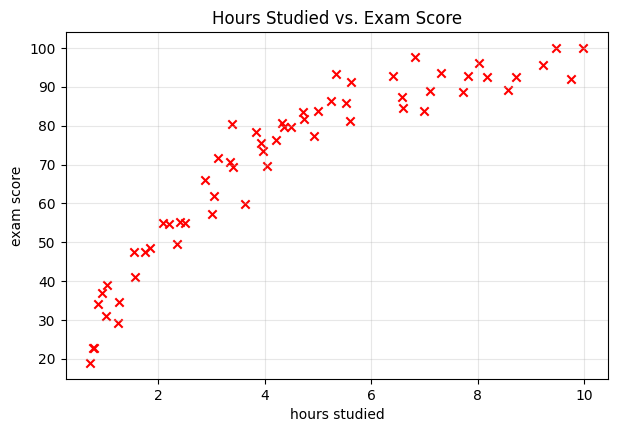

In [3]:
def plot_dataset(x, y, title, xlabel="x", ylabel="y"):
    # Scatter-plot a single input feature against the target.
    plt.figure(figsize=(7, 4.5))
    plt.scatter(x, y, marker='x', c='r')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    plt.show()

# Plot the entire dataset
plot_dataset(x, y, title="Hours Studied vs. Exam Score", xlabel="hours studied", ylabel="exam score")

### Split the dataset into training, cross validation, and test sets

Just like in the original lab, we hold out part of the data so we can measure how well the model
generalizes to examples it hasn't seen. We'll use the same common split:

* **training set (60%)** — used to fit the model
* **cross validation set (20%)** — used to compare different model configurations (e.g. which
  polynomial degree, or which neural network architecture, works best)
* **test set (20%)** — used only at the very end, to report a fair estimate of the chosen model's
  performance on new data

`scikit-learn`'s [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
makes this easy — we call it twice to get a 60/20/20 split.

In [4]:
# Get 60% of the dataset as the training set. Put the remaining 40% in temporary variables: x_ and y_.
x_train, x_, y_train, y_ = train_test_split(x, y, test_size=0.40, random_state=1)

# Split the 40% subset above into two: one half for cross validation and the other for the test set
x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.50, random_state=1)

# Delete temporary variables
del x_, y_

print(f"the shape of the training set (input) is: {x_train.shape}")
print(f"the shape of the training set (target) is: {y_train.shape}\n")
print(f"the shape of the cross validation set (input) is: {x_cv.shape}")
print(f"the shape of the cross validation set (target) is: {y_cv.shape}\n")
print(f"the shape of the test set (input) is: {x_test.shape}")
print(f"the shape of the test set (target) is: {y_test.shape}")

the shape of the training set (input) is: (36, 1)
the shape of the training set (target) is: (36, 1)

the shape of the cross validation set (input) is: (12, 1)
the shape of the cross validation set (target) is: (12, 1)

the shape of the test set (input) is: (12, 1)
the shape of the test set (target) is: (12, 1)


Let's visualize which points ended up in each split.

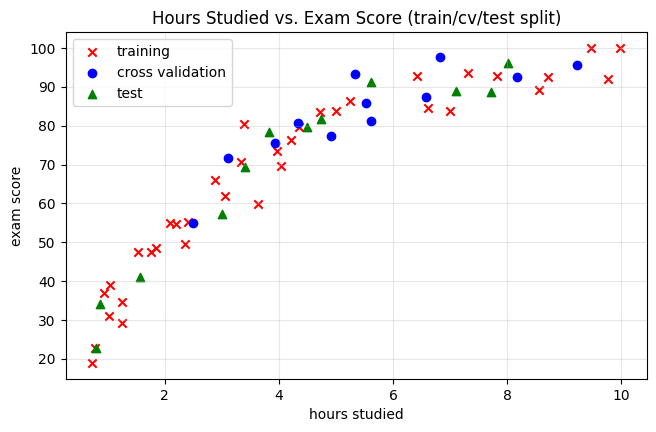

In [5]:
def plot_train_cv_test(x_train, y_train, x_cv, y_cv, x_test, y_test, title,
                         xlabel="x", ylabel="y"):
    # Scatter-plot the training, CV, and test splits in different colors.
    plt.figure(figsize=(7.5, 4.5))
    plt.scatter(x_train, y_train, marker='x', c='r', label='training')
    plt.scatter(x_cv, y_cv, marker='o', c='b', label='cross validation')
    plt.scatter(x_test, y_test, marker='^', c='g', label='test')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_train_cv_test(x_train, y_train, x_cv, y_cv, x_test, y_test,
                    title="Hours Studied vs. Exam Score (train/cv/test split)",
                    xlabel="hours studied", ylabel="exam score")

### Fit a linear model

#### Feature scaling

Before training, it's good practice to scale the inputs — this helps gradient-based optimizers
converge faster and matters even more once we add polynomial terms (since `x` and `x^2` can have
very different ranges). We'll use [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html),
which computes the z-score:

$$ z = \frac{x - \mu}{\sigma} $$

where $\mu$ is the mean and $\sigma$ is the standard deviation of the training set.

Computed mean of the training set: 4.19
Computed standard deviation of the training set: 2.82


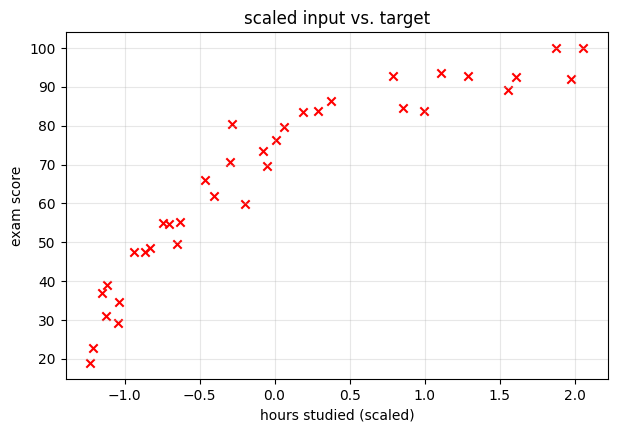

In [6]:
# Initialize the class
scaler_linear = StandardScaler()

# Compute the mean and standard deviation of the training set then transform it
X_train_scaled = scaler_linear.fit_transform(x_train)

print(f"Computed mean of the training set: {scaler_linear.mean_.squeeze():.2f}")
print(f"Computed standard deviation of the training set: {scaler_linear.scale_.squeeze():.2f}")

# Plot the results
plot_dataset(X_train_scaled, y_train, title="scaled input vs. target",
             xlabel="hours studied (scaled)", ylabel="exam score")

#### Train the model

Now let's fit a plain [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
model on the scaled training data.

In [7]:
# Initialize the class
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Evaluate the model

We'll measure performance with the mean squared error (MSE):

$$J_{train}(\vec{w}, b) = \frac{1}{2m_{train}}\left[\sum_{i=1}^{m_{train}}(f_{\vec{w},b}(\vec{x}_{train}^{(i)}) - y_{train}^{(i)})^2\right]$$

`scikit-learn`'s [`mean_squared_error()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)
divides by `m`, not `2m`, so we divide the result by 2 to match the convention above. A for-loop
version is included too, just to double check the two agree.

In [8]:
# Feed the scaled training set and get the predictions
yhat = linear_model.predict(X_train_scaled)

# Use scikit-learn's utility function and divide by 2
print(f"training MSE (using sklearn function): {mean_squared_error(y_train, yhat) / 2}")

# for-loop implementation
total_squared_error = 0
for i in range(len(yhat)):
    squared_error_i = (yhat[i] - y_train[i]) ** 2
    total_squared_error += squared_error_i

mse = total_squared_error / (2 * len(yhat))
print(f"training MSE (for-loop implementation): {mse.squeeze()}")

training MSE (using sklearn function): 47.51244605220047
training MSE (for-loop implementation): 47.51244605220046


Now the cross validation MSE. **Important**: we scale the CV set using the mean/standard
deviation that were computed on the *training* set (`transform()`, not `fit_transform()`), so the
model sees inputs prepared the same way it was trained on.

In [9]:
# Scale the cross validation set using the mean and standard deviation of the training set
X_cv_scaled = scaler_linear.transform(x_cv)

print(f"Mean used to scale the CV set: {scaler_linear.mean_.squeeze():.2f}")
print(f"Standard deviation used to scale the CV set: {scaler_linear.scale_.squeeze():.2f}")

# Feed the scaled cross validation set
yhat = linear_model.predict(X_cv_scaled)

# Use scikit-learn's utility function and divide by 2
print(f"Cross validation MSE: {mean_squared_error(y_cv, yhat) / 2}")

Mean used to scale the CV set: 4.19
Standard deviation used to scale the CV set: 2.82
Cross validation MSE: 50.3816617148804


### Adding polynomial features

The "hours studied vs. exam score" curve rises quickly at first and flattens out later — a
straight line can't capture that shape well. Let's see if adding polynomial features helps, using
[`PolynomialFeatures`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html).

First, a quick look at what a degree-2 transform produces (columns are `x`, `x^2`):

In [10]:
# Instantiate the class to make polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)

# Compute the number of features and transform the training set
X_train_mapped = poly.fit_transform(x_train)

# Preview the first 5 elements of the new training set. Left column is `x`, right column is `x^2`
print(X_train_mapped[:5])

[[ 7.32 53.57]
 [ 4.36 19.  ]
 [ 7.   48.98]
 [ 5.25 27.51]
 [ 8.72 76.11]]


In [11]:
# Instantiate the class
scaler_poly = StandardScaler()

# Compute the mean and standard deviation of the training set then transform it
X_train_mapped_scaled = scaler_poly.fit_transform(X_train_mapped)

# Preview the first 5 elements of the scaled training set.
print(X_train_mapped_scaled[:5])

[[ 1.11  0.95]
 [ 0.06 -0.22]
 [ 1.    0.8 ]
 [ 0.38  0.07]
 [ 1.61  1.72]]


Now let's automate this across degrees 1 through 10, tracking training and CV MSE for each
one, so we can see exactly where the model starts overfitting.

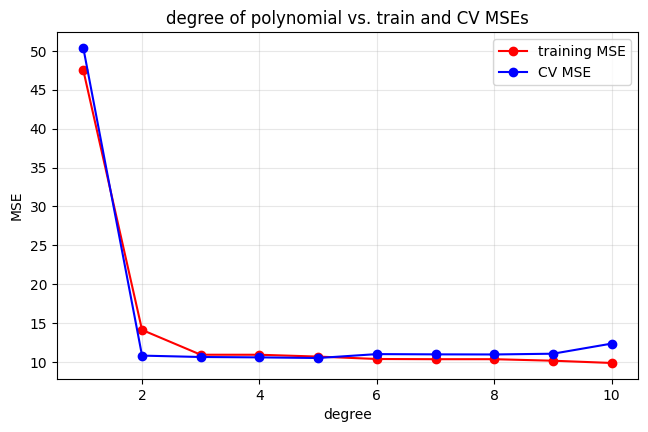

In [12]:
# Initialize lists to save the errors, models, and feature transforms
train_mses = []
cv_mses = []
models = []
polys = []
scalers = []

# Loop over degrees 1 to 10
for degree in range(1, 11):

    # Add polynomial features to the training set
    poly = PolynomialFeatures(degree, include_bias=False)
    X_train_mapped = poly.fit_transform(x_train)
    polys.append(poly)

    # Scale the training set
    scaler_poly = StandardScaler()
    X_train_mapped_scaled = scaler_poly.fit_transform(X_train_mapped)
    scalers.append(scaler_poly)

    # Create and train the model
    model = LinearRegression()
    model.fit(X_train_mapped_scaled, y_train)
    models.append(model)

    # Compute the training MSE
    yhat = model.predict(X_train_mapped_scaled)
    train_mse = mean_squared_error(y_train, yhat) / 2
    train_mses.append(train_mse)

    # Add polynomial features and scale the cross validation set
    X_cv_mapped = poly.transform(x_cv)
    X_cv_mapped_scaled = scaler_poly.transform(X_cv_mapped)

    # Compute the cross validation MSE
    yhat = model.predict(X_cv_mapped_scaled)
    cv_mse = mean_squared_error(y_cv, yhat) / 2
    cv_mses.append(cv_mse)

def plot_train_cv_mses(degrees, train_mses, cv_mses, title):
    # Line plot comparing training and CV error across polynomial degrees.
    plt.figure(figsize=(7.5, 4.5))
    plt.plot(degrees, train_mses, marker='o', c='r', label='training MSE')
    plt.plot(degrees, cv_mses, marker='o', c='b', label='CV MSE')
    plt.title(title)
    plt.xlabel('degree')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Plot the results
degrees = range(1, 11)
plot_train_cv_mses(degrees, train_mses, cv_mses, title="degree of polynomial vs. train and CV MSEs")

### Choosing the best model

We want the model that does well on **both** the training and cross validation sets — that's the
sign it learned real patterns without overfitting. Let's just pick the degree with the lowest CV
MSE automatically.

In [13]:
# Get the model with the lowest CV MSE (add 1 because list indices start at 0)
# This also corresponds to the degree of the polynomial added
degree = np.argmin(cv_mses) + 1
print(f"Lowest CV MSE is found in the model with degree={degree}")

Lowest CV MSE is found in the model with degree=5


Finally, report the generalization error using the untouched test set. As before, we apply
the *same* polynomial transform and scaler that were fit on the training data.

In [14]:
# Add polynomial features to the test set
X_test_mapped = polys[degree-1].transform(x_test)

# Scale the test set
X_test_mapped_scaled = scalers[degree-1].transform(X_test_mapped)

# Compute the test MSE
yhat = models[degree-1].predict(X_test_mapped_scaled)
test_mse = mean_squared_error(y_test, yhat) / 2

print(f"Training MSE: {train_mses[degree-1]:.2f}")
print(f"Cross Validation MSE: {cv_mses[degree-1]:.2f}")
print(f"Test MSE: {test_mse:.2f}")

Training MSE: 10.70
Cross Validation MSE: 10.52
Test MSE: 8.44


## Part 2: Neural Networks for Regression

Model selection isn't limited to picking a polynomial degree — the same idea applies to choosing
between different **neural network architectures**. Let's build 3 candidate networks of
increasing size/complexity and apply the same train → compare-on-CV → test workflow to the exam
score data.

### Prepare the data

We'll reuse the same `x_train` / `x_cv` / `x_test` splits from before. Neural networks can learn
non-linear relationships on their own, so we don't need to hand-engineer polynomial features —
we'll set `degree=1` (i.e., just use the raw `x` values) and let the network do the work.

In [15]:
# Add polynomial features (degree=1 means "just use x as is")
degree = 1
poly = PolynomialFeatures(degree, include_bias=False)
X_train_mapped = poly.fit_transform(x_train)
X_cv_mapped = poly.transform(x_cv)
X_test_mapped = poly.transform(x_test)

# Scale the features using the z-score
scaler = StandardScaler()
X_train_mapped_scaled = scaler.fit_transform(X_train_mapped)
X_cv_mapped_scaled = scaler.transform(X_cv_mapped)
X_test_mapped_scaled = scaler.transform(X_test_mapped)

### Build and train the models

The `build_models()` function below creates 3 small feed-forward networks — `model_1` is the
smallest (2 hidden layers), `model_2` is a bit wider/deeper, and `model_3` is the largest
(5 hidden layers). We'll train all three on the training set and compare their MSE on the CV set.

In [16]:
def build_models():
    # Return 3 candidate feed-forward regression networks of increasing complexity.
    tf.random.set_seed(20)

    model_1 = Sequential(
        [
            Input(shape=(1,)),
            Dense(25, activation='relu'),
            Dense(15, activation='relu'),
            Dense(1, activation='linear'),
        ],
        name='model_1'
    )

    model_2 = Sequential(
        [
            Input(shape=(1,)),
            Dense(20, activation='relu'),
            Dense(12, activation='relu'),
            Dense(12, activation='relu'),
            Dense(20, activation='relu'),
            Dense(1, activation='linear'),
        ],
        name='model_2'
    )

    model_3 = Sequential(
        [
            Input(shape=(1,)),
            Dense(32, activation='relu'),
            Dense(16, activation='relu'),
            Dense(8, activation='relu'),
            Dense(4, activation='relu'),
            Dense(12, activation='relu'),
            Dense(1, activation='linear'),
        ],
        name='model_3'
    )

    return [model_1, model_2, model_3]

In [17]:
# Initialize lists that will contain the errors for each model
nn_train_mses = []
nn_cv_mses = []

# Build the models
nn_models = build_models()

# Loop over the models
for model in nn_models:

    # Setup the loss and optimizer
    model.compile(
        loss='mse',
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    )

    print(f"Training {model.name}...")

    # Train the model
    model.fit(
        X_train_mapped_scaled, y_train,
        epochs=150,
        verbose=0
    )

    print("Done!\n")

    # Record the training MSE
    yhat = model.predict(X_train_mapped_scaled, verbose=0)
    train_mse = mean_squared_error(y_train, yhat) / 2
    nn_train_mses.append(train_mse)

    # Record the cross validation MSE
    yhat = model.predict(X_cv_mapped_scaled, verbose=0)
    cv_mse = mean_squared_error(y_cv, yhat) / 2
    nn_cv_mses.append(cv_mse)

# Print the results
print("RESULTS:")
for model_num in range(len(nn_train_mses)):
    print(
        f"Model {model_num+1}: Training MSE: {nn_train_mses[model_num]:.2f}, "
        f"CV MSE: {nn_cv_mses[model_num]:.2f}"
    )

Training model_1...


Done!



Training model_2...


Done!



Training model_3...


Done!



RESULTS:
Model 1: Training MSE: 48.05, CV MSE: 44.05
Model 2: Training MSE: 14.51, CV MSE: 10.45
Model 3: Training MSE: 14.40, CV MSE: 11.11


From the errors above, pick whichever model has the lowest CV MSE (breaking ties in favor
of the smaller/cheaper model is a common rule of thumb). Then compute the test MSE to report the
final generalization error.

In [18]:
# Select the model with the lowest CV MSE
model_num = int(np.argmin(nn_cv_mses)) + 1

# Compute the test MSE
yhat = nn_models[model_num-1].predict(X_test_mapped_scaled, verbose=0)
test_mse = mean_squared_error(y_test, yhat) / 2

print(f"Selected Model: {model_num}")
print(f"Training MSE: {nn_train_mses[model_num-1]:.2f}")
print(f"Cross Validation MSE: {nn_cv_mses[model_num-1]:.2f}")
print(f"Test MSE: {test_mse:.2f}")

Selected Model: 2
Training MSE: 14.51
Cross Validation MSE: 10.45
Test MSE: 8.29


## Part 3: Classification

In this last section, we'll practice the same evaluation/selection workflow on a **binary
classification** task. The main difference is how we measure error: instead of MSE, we'll use the
**fraction of misclassified examples**.

### Generate the dataset — "Network Traffic: Normal vs. Malicious"

Let's simulate a small cybersecurity-flavored dataset: for 200 network sessions we record the
**request rate** (`x1`, requests/second) and the **average payload size** (`x2`, in KB), and label
each session as normal (`0`) or malicious (`1`). We'll deliberately make the two classes **not**
linearly separable (using `make_moons` under the hood) — this mirrors real intrusion-detection
data, where a simple straight-line boundary usually isn't enough, and is exactly why we'll want to
compare a few neural network architectures rather than just eyeballing a threshold.

In [19]:
# Generate a non-linearly-separable 2-class dataset and reshape it to look like traffic stats
X_moons, y_moons = make_moons(n_samples=200, noise=0.25, random_state=1)

# request_rate: requests per second, roughly in the 0-55 range
request_rate = 25 + 15 * X_moons[:, 0]
# avg_payload_size: KB, roughly in the 0-115 range
avg_payload_size = 50 + 30 * X_moons[:, 1]

x_bc = np.column_stack([request_rate, avg_payload_size])
y_bc = np.expand_dims(y_moons.astype(float), axis=1)

print(f"the shape of the inputs x is: {x_bc.shape}")
print(f"the shape of the targets y is: {y_bc.shape}")

the shape of the inputs x is: (200, 2)
the shape of the targets y is: (200, 1)


Let's plot the dataset to see how the two classes are distributed.

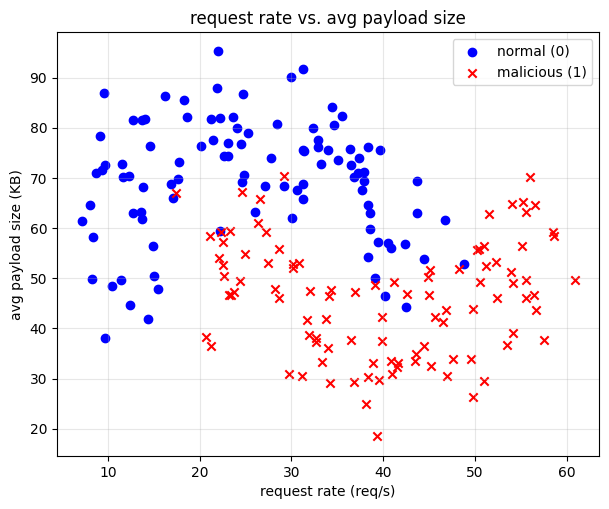

In [20]:
def plot_bc_dataset(x, y, title, xlabel="x1", ylabel="x2"):
    # Scatter-plot a 2-feature binary classification dataset.
    y = y.flatten()
    plt.figure(figsize=(7, 5.5))
    plt.scatter(x[y == 0, 0], x[y == 0, 1], marker='o', c='b', label='normal (0)')
    plt.scatter(x[y == 1, 0], x[y == 1, 1], marker='x', c='r', label='malicious (1)')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_bc_dataset(x=x_bc, y=y_bc, title="request rate vs. avg payload size",
                 xlabel="request rate (req/s)", ylabel="avg payload size (KB)")

### Split and prepare the dataset

Same 60/20/20 split as before, plus feature scaling.

In [21]:
# Get 60% of the dataset as the training set. Put the remaining 40% in temporary variables.
x_bc_train, x_, y_bc_train, y_ = train_test_split(x_bc, y_bc, test_size=0.40, random_state=1)

# Split the 40% subset above into two: one half for cross validation and the other for the test set
x_bc_cv, x_bc_test, y_bc_cv, y_bc_test = train_test_split(x_, y_, test_size=0.50, random_state=1)

# Delete temporary variables
del x_, y_

print(f"the shape of the training set (input) is: {x_bc_train.shape}")
print(f"the shape of the training set (target) is: {y_bc_train.shape}\n")
print(f"the shape of the cross validation set (input) is: {x_bc_cv.shape}")
print(f"the shape of the cross validation set (target) is: {y_bc_cv.shape}\n")
print(f"the shape of the test set (input) is: {x_bc_test.shape}")
print(f"the shape of the test set (target) is: {y_bc_test.shape}")

the shape of the training set (input) is: (120, 2)
the shape of the training set (target) is: (120, 1)

the shape of the cross validation set (input) is: (40, 2)
the shape of the cross validation set (target) is: (40, 1)

the shape of the test set (input) is: (40, 2)
the shape of the test set (target) is: (40, 1)


In [22]:
# Scale the features

# Initialize the class
scaler_bc = StandardScaler()

# Compute the mean and standard deviation of the training set then transform it
x_bc_train_scaled = scaler_bc.fit_transform(x_bc_train)
x_bc_cv_scaled = scaler_bc.transform(x_bc_cv)
x_bc_test_scaled = scaler_bc.transform(x_bc_test)

### Evaluating the error for classification models

For classification, the error is just the fraction of examples the model got wrong. For example,
if the model misclassifies 2 out of 5 sessions, the error is `2/5 = 0.4`. Here's a tiny example
with both a for-loop and `numpy`'s `mean()` to show they agree.

In [23]:
# Sample model output
probabilities = np.array([0.2, 0.6, 0.7, 0.3, 0.8])

# Apply a threshold to the model output. If greater than 0.5, set to 1. Else 0.
predictions = np.where(probabilities >= 0.5, 1, 0)

# Ground truth labels
ground_truth = np.array([1, 1, 1, 1, 1])

# Initialize counter for misclassified data
misclassified = 0
num_predictions = len(predictions)

for i in range(num_predictions):
    if predictions[i] != ground_truth[i]:
        misclassified += 1

fraction_error = misclassified / num_predictions

print(f"probabilities: {probabilities}")
print(f"predictions with threshold=0.5: {predictions}")
print(f"targets: {ground_truth}")
print(f"fraction of misclassified data (for-loop): {fraction_error}")
print(f"fraction of misclassified data (with np.mean()): {np.mean(predictions != ground_truth)}")

probabilities: [0.2 0.6 0.7 0.3 0.8]
predictions with threshold=0.5: [0 1 1 0 1]
targets: [1 1 1 1 1]
fraction of misclassified data (for-loop): 0.4
fraction of misclassified data (with np.mean()): 0.4


### Build and train the models

We'll reuse the same 3 candidate architectures as before (just re-built fresh, with an input layer
sized for 2 features this time). Following the recommended approach, the output layer uses a
`linear` activation instead of `sigmoid`, and we set `from_logits=True` in the loss
([`BinaryCrossentropy`](https://www.tensorflow.org/api_docs/python/tf/keras/losses/BinaryCrossentropy),
since this is binary classification). After training, we apply a
[`sigmoid`](https://www.tensorflow.org/api_docs/python/tf/math/sigmoid) to turn the raw outputs
into probabilities, threshold them, and compute the misclassification rate.

In [24]:
def build_models_bc():
    # Return 3 candidate feed-forward classification networks of increasing complexity.
    tf.random.set_seed(20)

    model_1 = Sequential(
        [
            Input(shape=(2,)),
            Dense(25, activation='relu'),
            Dense(15, activation='relu'),
            Dense(1, activation='linear'),
        ],
        name='model_1'
    )

    model_2 = Sequential(
        [
            Input(shape=(2,)),
            Dense(20, activation='relu'),
            Dense(12, activation='relu'),
            Dense(12, activation='relu'),
            Dense(20, activation='relu'),
            Dense(1, activation='linear'),
        ],
        name='model_2'
    )

    model_3 = Sequential(
        [
            Input(shape=(2,)),
            Dense(32, activation='relu'),
            Dense(16, activation='relu'),
            Dense(8, activation='relu'),
            Dense(4, activation='relu'),
            Dense(12, activation='relu'),
            Dense(1, activation='linear'),
        ],
        name='model_3'
    )

    return [model_1, model_2, model_3]

In [25]:
# Initialize lists that will contain the errors for each model
nn_train_error = []
nn_cv_error = []

# Build the models
models_bc = build_models_bc()

# Loop over each model
for model in models_bc:

    # Setup the loss and optimizer
    model.compile(
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    )

    print(f"Training {model.name}...")

    # Train the model
    model.fit(
        x_bc_train_scaled, y_bc_train,
        epochs=150,
        verbose=0
    )

    print("Done!\n")

    # Set the threshold for classification
    threshold = 0.5

    # Record the fraction of misclassified examples for the training set
    yhat = model.predict(x_bc_train_scaled, verbose=0)
    yhat = tf.math.sigmoid(yhat)
    yhat = np.where(yhat >= threshold, 1, 0)
    train_error = np.mean(yhat != y_bc_train)
    nn_train_error.append(train_error)

    # Record the fraction of misclassified examples for the cross validation set
    yhat = model.predict(x_bc_cv_scaled, verbose=0)
    yhat = tf.math.sigmoid(yhat)
    yhat = np.where(yhat >= threshold, 1, 0)
    cv_error = np.mean(yhat != y_bc_cv)
    nn_cv_error.append(cv_error)

# Print the result
for model_num in range(len(nn_train_error)):
    print(
        f"Model {model_num+1}: Training Set Classification Error: {nn_train_error[model_num]:.5f}, "
        f"CV Set Classification Error: {nn_cv_error[model_num]:.5f}"
    )

Training model_1...


Done!

Training model_2...


Done!



Training model_3...


Done!



Model 1: Training Set Classification Error: 0.03333, CV Set Classification Error: 0.07500
Model 2: Training Set Classification Error: 0.01667, CV Set Classification Error: 0.07500
Model 3: Training Set Classification Error: 0.01667, CV Set Classification Error: 0.10000


From the output above, pick whichever model performed best on the CV set (breaking ties by
preferring the smaller model, since that saves compute). Then compute the test error to report the
model's generalization error.

In [26]:
# Select the model with the lowest CV error
model_num = int(np.argmin(nn_cv_error)) + 1

# Compute the test error
threshold = 0.5
yhat = models_bc[model_num-1].predict(x_bc_test_scaled, verbose=0)
yhat = tf.math.sigmoid(yhat)
yhat = np.where(yhat >= threshold, 1, 0)
nn_test_error = np.mean(yhat != y_bc_test)

print(f"Selected Model: {model_num}")
print(f"Training Set Classification Error: {nn_train_error[model_num-1]:.4f}")
print(f"CV Set Classification Error: {nn_cv_error[model_num-1]:.4f}")
print(f"Test Set Classification Error: {nn_test_error:.4f}")

Selected Model: 1
Training Set Classification Error: 0.0333
CV Set Classification Error: 0.0750
Test Set Classification Error: 0.0500


## Wrap Up

In this notebook, I practiced evaluating model performance and choosing between different model
configurations, using two brand-new synthetic datasets (an exam-score regression task and a
network-traffic classification task) instead of the original lab data. I covered:

* splitting data into training, cross validation, and test sets, and why each one matters
* using CV error (not test error!) to make model-selection decisions along the way
* using polynomial features to help a linear model fit a non-linear regression curve, and picking
  the best degree with the CV set
* comparing multiple neural network architectures for both regression and classification, and
  selecting the best one based on CV performance before finally reporting test performance

Next step: use these same ideas to diagnose **bias vs. variance** and figure out *why* a model is
underperforming, not just *whether* it is.